In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, roc_auc_score

# Load raw datasets
cust_raw = pd.read_csv('customers_data.csv')
trans_raw = pd.read_csv('transactions_data.csv')
prod_raw = pd.read_csv('products_data.csv')

In [3]:
# --- Cleaning Products ---
prod_raw['Product_Price'] = prod_raw['Product_Price'].astype(str).str.replace('₱', '', regex=False).str.replace(',', '', regex=False).str.replace('?', '', regex=False).astype(float)
prod_raw['Product_ID'] = prod_raw['Product_ID'].fillna(pd.Series(prod_raw.index + 1)).astype(int)

# --- Cleaning Customers ---
cust_raw['Company_Profit'] = cust_raw['Company_Profit'].fillna(cust_raw['Company_Profit'].median())
cust_raw['City'] = cust_raw['Address'].apply(lambda x: x.split(',')[-2].strip().title() if len(str(x).split(',')) >= 2 else 'Unknown')

# --- Cleaning Transactions ---
trans_raw['Transaction_Date'] = pd.to_datetime(trans_raw['Transaction_Date'], format='mixed', errors='coerce')
trans_raw = trans_raw.dropna(subset=['Transaction_Date'])
price_map = prod_raw.set_index('Product_ID')['Product_Price'].to_dict()
trans_raw['Product_Price'] = trans_raw['Product_Price'].fillna(trans_raw['Product_ID'].map(price_map))
trans_raw['Quantity'] = trans_raw['Quantity'].fillna(1.0)
trans_raw['Total_Cost'] = trans_raw['Total_Cost'].fillna(trans_raw['Quantity'] * trans_raw['Product_Price'])

In [5]:
# Monthly Aggregation for Forecasting
trans_raw['YearMonth'] = trans_raw['Transaction_Date'].dt.to_period('M')
monthly_sales = trans_raw.groupby('YearMonth')['Total_Cost'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].dt.to_timestamp()

# Creating Lags
monthly_sales['Lag_1'] = monthly_sales['Total_Cost'].shift(1)
monthly_sales['Lag_2'] = monthly_sales['Total_Cost'].shift(2)
monthly_sales['Rolling_Mean_3'] = monthly_sales['Total_Cost'].shift(1).rolling(window=3).mean()

# Define Month/Year
monthly_sales['Month'] = monthly_sales['YearMonth'].dt.month
monthly_sales['Year'] = monthly_sales['YearMonth'].dt.year

df_forecast = monthly_sales.dropna()
df_forecast.to_csv('monthly_sales_history_features.csv', index=False)

In [7]:
# Training
X_cols = ['Month', 'Year', 'Lag_1', 'Lag_2', 'Rolling_Mean_3']
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(df_forecast[X_cols], df_forecast['Total_Cost'])

# 3-Month Iterative Forecast (Jan - Mar 2025)
future_dates = pd.date_range(start='2025-01-01', periods=3, freq='MS')
forecast_results = []
current_input = df_forecast.iloc[-1].copy()

for date in future_dates:
    X_future = pd.DataFrame([[date.month, date.year, current_input['Total_Cost'], 
                              current_input['Lag_1'], current_input['Rolling_Mean_3']]], columns=X_cols)
    pred = model_rf.predict(X_future)[0]
    forecast_results.append({'YearMonth': date, 'Predicted_Sales': pred})
    
    # Update state for next step
    current_input['Lag_1'] = current_input['Total_Cost']
    current_input['Total_Cost'] = pred

forecast_df = pd.DataFrame(forecast_results)
forecast_df.to_csv('sales_forecast_3_months.csv', index=False)

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


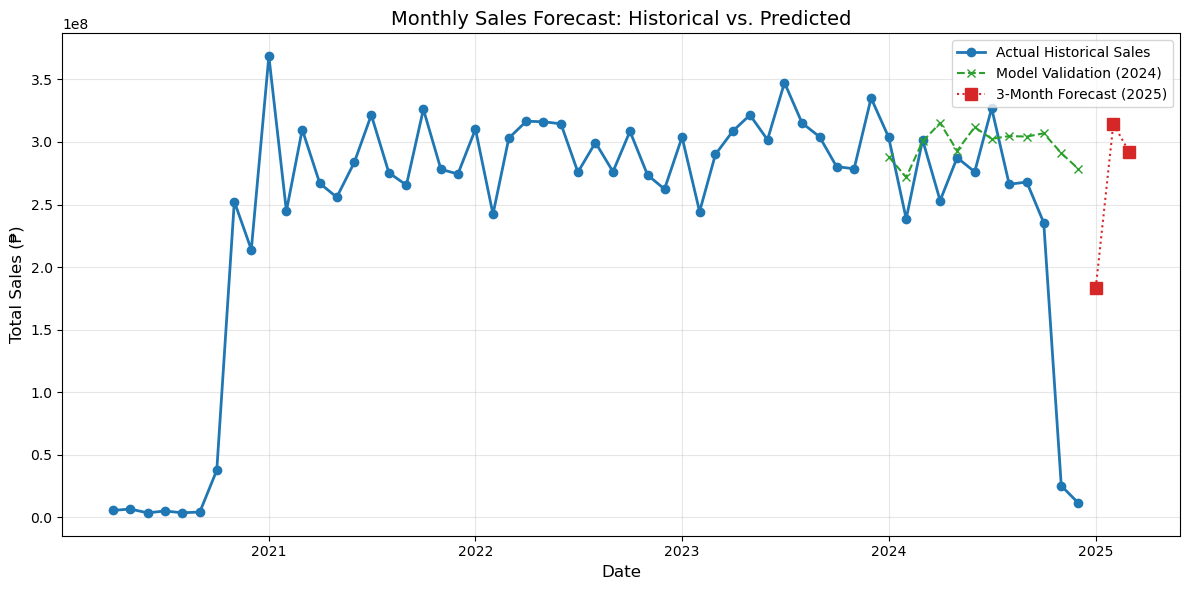

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Load and Clean Data
trans = pd.read_csv('transactions_data.csv')
trans['Transaction_Date'] = pd.to_datetime(trans['Transaction_Date'], format='mixed')

# 2. Resample to Monthly Sales
monthly_sales = trans.set_index('Transaction_Date')['Total_Cost'].resample('MS').sum().reset_index()
monthly_sales['Month'] = monthly_sales['Transaction_Date'].dt.month
monthly_sales['Year'] = monthly_sales['Transaction_Date'].dt.year

# 3. Create Lag Features (Critical for Time Series)
monthly_sales['Lag_1'] = monthly_sales['Total_Cost'].shift(1)
monthly_sales['Rolling_3'] = monthly_sales['Total_Cost'].shift(1).rolling(window=3).mean()
df = monthly_sales.dropna()

# 4. Split into Historical and Validation (2024 as Test)
train = df[df['Year'] < 2024]
test = df[df['Year'] == 2024]
X_cols = ['Month', 'Year', 'Lag_1', 'Rolling_3']

# 5. Train Model and Predict 2025
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(train[X_cols], train['Total_Cost'])
test_preds = model.predict(test[X_cols])

# Generate 3-Month Future Forecast (Recursive)
future_dates = pd.date_range(start='2025-01-01', periods=3, freq='MS')
last_val = df.iloc[-1]['Total_Cost']
last_roll = df.iloc[-1]['Rolling_3']
forecast = []

for date in future_dates:
    pred = model.predict([[date.month, date.year, last_val, last_roll]])[0]
    forecast.append(pred)
    last_val = pred # Update lag for next step

# 6. Visualization Code
plt.figure(figsize=(12, 6))

# Plot Actual History
plt.plot(df['Transaction_Date'], df['Total_Cost'], label='Actual Historical Sales', 
         color='#1f77b4', marker='o', linewidth=2)

# Plot Validation (Test Set)
plt.plot(test['Transaction_Date'], test_preds, label='Model Validation (2024)', 
         color='#2ca02c', linestyle='--', marker='x')

# Plot 3-Month Forecast
plt.plot(future_dates, forecast, label='3-Month Forecast (2025)', 
         color='#d62728', linestyle=':', marker='s', markersize=8)

plt.title('Monthly Sales Forecast: Historical vs. Predicted', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales (₱)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Explanation of the Chart
#This chart is a Time-Series Diagnostic Tool. It serves three distinct business purposes represented by the three different lines:

#Blue Line (Actual Historical Sales): 
#What it represents: This is the "ground truth." It shows the real revenue generated month-over-month.
#Insight: It allows stakeholders to see natural volatility, seasonal peaks (like year-end surges), and historical growth trends.

#Green Dashed Line (Model Validation):
#What it represents: The model is asked to predict a year it hasn't "seen" during training (2024). We then compare those predictions to the actual blue line for that same period.
#Insight: If the green line closely follows the blue line, it proves the model is trustworthy. If they diverge significantly, the model needs more features or a different algorithm.

#Red Dotted Line (3-Month Forecast): 
#What it represents: The "Forward-Looking" component. Based on the patterns found in the history and validation steps, the model projects the next 90 days.
#Insight: This is used for Resource Planning. For example, if the red line shows a steep climb for March 2025, the business knows to increase inventory or staff ahead of time.